# Paper 8: SSVEP DSS Benchmark

With an SSVEP dataset, DSS benchmarking is really clean because we have an
explicit **ground-truth target**: power/phase at the stimulation frequency (and harmonics).

**Pipeline overview:**

1. Minimal preprocessing (average re-reference, 0.1 Hz high-pass — conservative for SSVEP)
2. Epoch around SSVEP trials; analyse only the steady-state window (skip onset transient)
3. Compute PSD and SNR spectrum (MNE tutorial method)
4. Apply DSS with `ssvep_dss` (comb-filter bias at fundamental + harmonics). **Critical**: fit on *training* epochs, evaluate on *held-out* epochs (no double-dipping).
5. Compare to gold standards:
   - **(a)** Occipital-ROI SNR (analysis baseline — what MNE teaches)
   - **(b)** Standard CCA (decoding baseline — template-based, no training needed)

Based on the [MNE SSVEP tutorial](https://mne.tools/stable/auto_tutorials/time-freq/50_ssvep.html).

In [39]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_rel

import mne
from mne_denoise.dss import DSS, ssvep_dss

## Step 1 — Load data and minimal preprocessing

Conservative preprocessing for SSVEP — we don't want to distort the narrowband
frequency tagging:

- Common-average re-reference
- 0.1 Hz high-pass only (remove drift, no low-pass)
- Set the standard montage

In [53]:
# Load raw data
data_path = mne.datasets.ssvep.data_path()
bids_fname = (
    data_path / "sub-02" / "ses-01" / "eeg" / "sub-02_ses-01_task-ssvep_eeg.vhdr"
)
raw = mne.io.read_raw_brainvision(bids_fname, preload=True, verbose=False)
raw.info["line_freq"] = 50.0

# Set montage
montage = mne.channels.make_standard_montage("easycap-M1")
raw.set_montage(montage, verbose=False)

# Common-average re-reference
raw.set_eeg_reference("average", projection=False, verbose=False)

# Light high-pass filter only (no low-pass — preserve SSVEP harmonics)
raw.filter(l_freq=0.1, h_freq=None, fir_design="firwin", verbose=False)

<RawBrainVision | sub-02_ses-01_task-ssvep_eeg.eeg, 32 x 467580 (467.6 s), ~114.2 MiB, data loaded>

## Step 2 — Epoching

Epoch around SSVEP trials (−1 to 20 s). We'll analyse only the steady-state
portion later (t = 1…20 s), skipping the onset transient.

In [54]:
# Rename annotations to friendly labels (same as MNE tutorial)
raw.annotations.rename({"Stimulus/S255": "12hz", "Stimulus/S155": "15hz"})

tmin, tmax = -1.0, 20.0
epochs = mne.Epochs(
    raw,
    event_id=["12hz", "15hz"],
    tmin=tmin,
    tmax=tmax,
    baseline=None,
    preload=True,
    verbose=False,
)

print(epochs)
print(f"  12 Hz trials: {len(epochs['12hz'])}")
print(f"  15 Hz trials: {len(epochs['15hz'])}")

<Epochs | 20 events (all good), -1 – 20 s (baseline off), ~102.6 MiB, data loaded,
 np.str_('12hz'): 10
 np.str_('15hz'): 10>
  12 Hz trials: 10
  15 Hz trials: 10


## Step 3 — Frequency analysis (PSD and SNR spectrum)

We use the same approach as the MNE SSVEP tutorial:

- **PSD**: plain FFT via Welch with a single boxcar window spanning the steady-state portion (1–20 s)
- **SNR**: ratio of power at each frequency bin to the mean power in neighboring bins (Meigen & Bach 1999)

In [55]:
# --- SNR helper (from MNE tutorial) ---
def snr_spectrum(psd, noise_n_neighbor_freqs=1, noise_skip_neighbor_freqs=1):
    """Compute SNR spectrum from PSD using convolution.

    SNR = power_bin / mean(power_in_neighboring_bins).
    """
    averaging_kernel = np.concatenate((
        np.ones(noise_n_neighbor_freqs),
        np.zeros(2 * noise_skip_neighbor_freqs + 1),
        np.ones(noise_n_neighbor_freqs),
    ))
    averaging_kernel /= averaging_kernel.sum()

    mean_noise = np.apply_along_axis(
        lambda psd_: np.convolve(psd_, averaging_kernel, mode="valid"),
        axis=-1, arr=psd,
    )
    edge_width = noise_n_neighbor_freqs + noise_skip_neighbor_freqs
    pad_width = [(0, 0)] * (mean_noise.ndim - 1) + [(edge_width, edge_width)]
    mean_noise = np.pad(mean_noise, pad_width=pad_width, constant_values=np.nan)
    return psd / mean_noise


# --- PSD parameters (steady-state portion only) ---
tmin_psd, tmax_psd = 1.0, 20.0
fmin, fmax = 1.0, 90.0
sfreq = epochs.info["sfreq"]

spectrum = epochs.compute_psd(
    "welch",
    n_fft=int(sfreq * (tmax_psd - tmin_psd)),
    n_overlap=0,
    n_per_seg=None,
    tmin=tmin_psd,
    tmax=tmax_psd,
    fmin=fmin,
    fmax=fmax,
    window="boxcar",
    verbose=False,
)
psds, freqs = spectrum.get_data(return_freqs=True)

# SNR: 3 neighbor bins on each side, skip 1 immediate neighbor
snrs = snr_spectrum(psds, noise_n_neighbor_freqs=3, noise_skip_neighbor_freqs=1)
print(f"PSD shape: {psds.shape}  (n_epochs, n_channels, n_freqs)")
print(f"Freq resolution: {freqs[1] - freqs[0]:.4f} Hz")

PSD shape: (20, 32, 1692)  (n_epochs, n_channels, n_freqs)
Freq resolution: 0.0526 Hz


### Plot PSD and SNR spectra

Grand average PSD (log scale) and SNR spectrum. You should see clear peaks at
12 Hz, 15 Hz and their harmonics in both plots. The SNR spectrum removes the
1/f decay and broadband power modulations.

C:\Users\s\AppData\Local\Temp\ipykernel_28464\3022701097.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


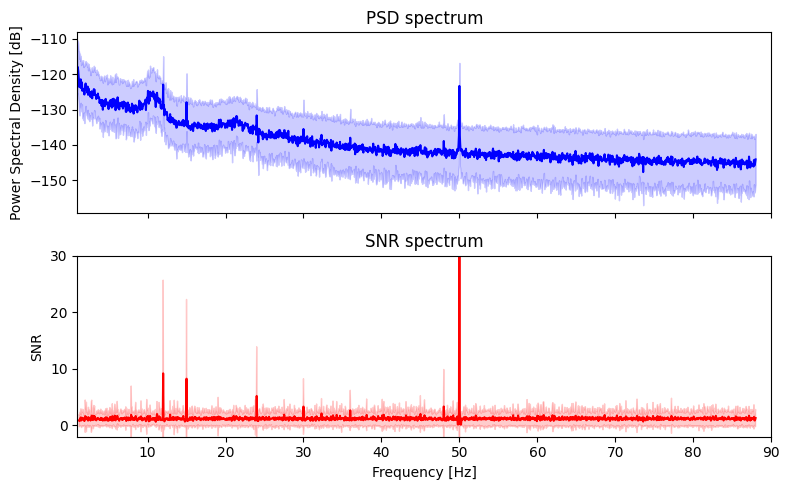

In [56]:
fig, axes = plt.subplots(2, 1, sharex="all", sharey="none", figsize=(8, 5))
freq_range = range(
    np.where(np.floor(freqs) == 1.0)[0][0],
    np.where(np.ceil(freqs) == fmax - 1)[0][0],
)

# PSD (dB)
psds_plot = 10 * np.log10(psds)
psds_mean = psds_plot.mean(axis=(0, 1))[freq_range]
psds_std = psds_plot.std(axis=(0, 1))[freq_range]
axes[0].plot(freqs[freq_range], psds_mean, color="b")
axes[0].fill_between(
    freqs[freq_range], psds_mean - psds_std, psds_mean + psds_std,
    color="b", alpha=0.2,
)
axes[0].set(title="PSD spectrum", ylabel="Power Spectral Density [dB]")

# SNR
snr_mean = snrs.mean(axis=(0, 1))[freq_range]
snr_std = snrs.std(axis=(0, 1))[freq_range]
axes[1].plot(freqs[freq_range], snr_mean, color="r")
axes[1].fill_between(
    freqs[freq_range], snr_mean - snr_std, snr_mean + snr_std,
    color="r", alpha=0.2,
)
axes[1].set(
    title="SNR spectrum", xlabel="Frequency [Hz]",
    ylabel="SNR", ylim=[-2, 30], xlim=[fmin, fmax],
)
fig.tight_layout()
fig.show()

### Occipital ROI — baseline SNR (Gold Standard #1)

Extract SNR at the target frequency for an occipital ROI.
This is the standard analysis baseline for SSVEP.

=== Gold Standard #1: Occipital ROI SNR ===
  12 Hz trials, SNR at 12 Hz (occ ROI): 41.69
  15 Hz trials, SNR at 15 Hz (occ ROI): 29.80


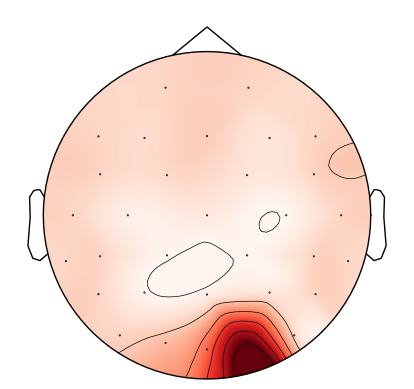

C:\Users\s\AppData\Local\Temp\ipykernel_28464\3539024650.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


In [57]:
# Define visual ROI
roi_vis = [
    "POz", "Oz", "O1", "O2", "PO3", "PO4", "PO7", "PO8", "PO9", "PO10", "O9", "O10",
]
picks_roi_vis = mne.pick_types(
    epochs.info, eeg=True, stim=False, exclude="bads", selection=roi_vis,
)

# Frequency bin indices
i_bin_12hz = np.argmin(abs(freqs - 12.0))
i_bin_15hz = np.argmin(abs(freqs - 15.0))
i_bin_24hz = np.argmin(abs(freqs - 24.0))
i_bin_30hz = np.argmin(abs(freqs - 30.0))
i_bin_36hz = np.argmin(abs(freqs - 36.0))
i_bin_45hz = np.argmin(abs(freqs - 45.0))

# Trial indices
i_trial_12hz = np.where(epochs.annotations.description == "12hz")[0]
i_trial_15hz = np.where(epochs.annotations.description == "15hz")[0]

# Baseline occipital-ROI SNR at target frequencies
snr_12_roi = snrs[i_trial_12hz, :, i_bin_12hz][:, picks_roi_vis]
snr_15_roi = snrs[i_trial_15hz, :, i_bin_15hz][:, picks_roi_vis]

print("=== Gold Standard #1: Occipital ROI SNR ===")
print(f"  12 Hz trials, SNR at 12 Hz (occ ROI): {snr_12_roi.mean():.2f}")
print(f"  15 Hz trials, SNR at 15 Hz (occ ROI): {snr_15_roi.mean():.2f}")

# Topography of 12 Hz response
snrs_12hz_all = snrs[i_trial_12hz, :, i_bin_12hz].mean(axis=0)
fig, ax = plt.subplots(1)
mne.viz.plot_topomap(snrs_12hz_all, epochs.info, vlim=(1, None), axes=ax)
ax.set_title("12 Hz SNR Topography (original)")
fig.show()

### Statistical separation of 12 Hz vs 15 Hz (before DSS)

Bar chart of SNR at target frequencies and harmonics in both trial types,
averaged over the occipital ROI. This is the baseline for comparison.

  12 Hz trials: 12 Hz SNR vs 15 Hz SNR — t=7.510, p=3.654e-05
  15 Hz trials: 15 Hz SNR vs 12 Hz SNR — t=5.692, p=0.0002974


C:\Users\s\AppData\Local\Temp\ipykernel_28464\1446130612.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


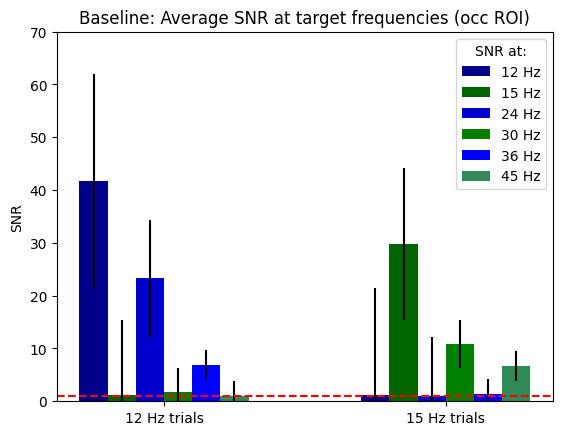

In [58]:
# Average SNR over occipital ROI
snrs_roi = snrs[:, picks_roi_vis, :].mean(axis=1)

freq_plot = [12, 15, 24, 30, 36, 45]
color_plot = ["darkblue", "darkgreen", "mediumblue", "green", "blue", "seagreen"]
xpos_plot = [-5.0 / 12, -3.0 / 12, -1.0 / 12, 1.0 / 12, 3.0 / 12, 5.0 / 12]
labels = ["12 Hz trials", "15 Hz trials"]
x = np.arange(len(labels))
width = 0.6
res_orig = dict()

fig, ax = plt.subplots()
for i, f in enumerate(freq_plot):
    stim_12hz_tmp = snrs_roi[i_trial_12hz, np.argmin(abs(freqs - f))]
    stim_15hz_tmp = snrs_roi[i_trial_15hz, np.argmin(abs(freqs - f))]
    SNR_tmp = [stim_12hz_tmp.mean(), stim_15hz_tmp.mean()]
    ax.bar(
        x + width * xpos_plot[i], SNR_tmp, width / len(freq_plot),
        yerr=np.std(SNR_tmp), label=f"{f} Hz SNR", color=color_plot[i],
    )
    res_orig[f"stim_12hz_snrs_{f}hz"] = stim_12hz_tmp
    res_orig[f"stim_15hz_snrs_{f}hz"] = stim_15hz_tmp

ax.set_ylabel("SNR")
ax.set_title("Baseline: Average SNR at target frequencies (occ ROI)")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend([f"{f} Hz" for f in freq_plot], title="SNR at:")
ax.set_ylim([0, 70])
ax.axhline(1, ls="--", c="r")
fig.show()

# T-tests
for label, i_trials, f_stim, f_other in [
    ("12 Hz", i_trial_12hz, 12, 15),
    ("15 Hz", i_trial_15hz, 15, 12),
]:
    t, p = ttest_rel(
        res_orig[f"stim_{label[:2]}hz_snrs_{f_stim}hz"],
        res_orig[f"stim_{label[:2]}hz_snrs_{f_other}hz"],
    )
    print(f"  {label} trials: {f_stim} Hz SNR vs {f_other} Hz SNR — t={t:.3f}, p={p:.4g}")

## Step 4 — Apply DSS (the key step)

We use `ssvep_dss()` which configures DSS with a comb-filter bias at the
fundamental + harmonics. This is the SSVEP-optimal denoising approach.

**Critical benchmarking rule**: to be publishable we must avoid double-dipping.
We fit DSS on *training* epochs and evaluate SNR on *held-out* test epochs.

We fit a separate DSS per target frequency (12 Hz condition, 15 Hz condition).

In [59]:
# --- Train/test split ---
# Use odd-indexed epochs for fitting, even-indexed for evaluation
epochs_12 = epochs["12hz"]
epochs_15 = epochs["15hz"]

n_12 = len(epochs_12)
n_15 = len(epochs_15)
idx_train_12 = np.arange(0, n_12, 2)  # even indices = train
idx_test_12 = np.arange(1, n_12, 2)   # odd indices = test
idx_train_15 = np.arange(0, n_15, 2)
idx_test_15 = np.arange(1, n_15, 2)

print(f"12 Hz: {len(idx_train_12)} train, {len(idx_test_12)} test epochs")
print(f"15 Hz: {len(idx_train_15)} train, {len(idx_test_15)} test epochs")

# Crop to steady-state window for DSS fitting
epochs_12_steady = epochs_12.copy().crop(tmin_psd, tmax_psd)
epochs_15_steady = epochs_15.copy().crop(tmin_psd, tmax_psd)

12 Hz: 5 train, 5 test epochs
15 Hz: 5 train, 5 test epochs


In [60]:
# --- Fit DSS per frequency (on TRAIN epochs only) ---
n_components = 5

# 12 Hz DSS
dss_12 = ssvep_dss(
    sfreq=sfreq, stim_freq=12.0, n_harmonics=3,
    n_components=n_components, return_type="epochs",
)
dss_12.fit(epochs_12_steady[idx_train_12])

# 15 Hz DSS
dss_15 = ssvep_dss(
    sfreq=sfreq, stim_freq=15.0, n_harmonics=3,
    n_components=n_components, return_type="epochs",
)
dss_15.fit(epochs_15_steady[idx_train_15])

print(f"12 Hz DSS eigenvalues: {dss_12.eigenvalues_}")
print(f"15 Hz DSS eigenvalues: {dss_15.eigenvalues_}")

E:\PhD\mne-denoise\mne_denoise\dss\linear.py:496: RuntimeWarning: Epochs are not baseline corrected, covariance matrix may be inaccurate
  baseline_cov = mne.compute_covariance(inst, method=method, **kws)
E:\PhD\mne-denoise\mne_denoise\dss\linear.py:498: RuntimeWarning: Epochs are not baseline corrected, covariance matrix may be inaccurate
  biased_cov = mne.compute_covariance(biased_inst, method=method, **kws)
E:\PhD\mne-denoise\mne_denoise\dss\linear.py:496: RuntimeWarning: Epochs are not baseline corrected, covariance matrix may be inaccurate
  baseline_cov = mne.compute_covariance(inst, method=method, **kws)
E:\PhD\mne-denoise\mne_denoise\dss\linear.py:498: RuntimeWarning: Epochs are not baseline corrected, covariance matrix may be inaccurate
  biased_cov = mne.compute_covariance(biased_inst, method=method, **kws)


12 Hz DSS eigenvalues: [0.10498    0.01724255 0.00917387 0.00768808 0.00475146]
15 Hz DSS eigenvalues: [0.05112592 0.00668229 0.00498387 0.00435905 0.00427321]


In [61]:
# --- Apply DSS to HELD-OUT test epochs (denoised back in sensor space) ---
epochs_12_test = epochs_12_steady[idx_test_12]
epochs_15_test = epochs_15_steady[idx_test_15]

epochs_12_dss = dss_12.transform(epochs_12_test)
epochs_15_dss = dss_15.transform(epochs_15_test)

print(f"Denoised 12 Hz test epochs: {epochs_12_dss}")
print(f"Denoised 15 Hz test epochs: {epochs_15_dss}")

Denoised 12 Hz test epochs: <EpochsArray | 5 events (all good), 1 – 20 s (baseline off), ~23.2 MiB, data loaded,
 np.str_('12hz'): 5>
Denoised 15 Hz test epochs: <EpochsArray | 5 events (all good), 1 – 20 s (baseline off), ~23.2 MiB, data loaded,
 np.str_('15hz'): 5>


### Compare SNR: Original vs DSS-denoised (held-out test set)

We recompute PSD → SNR on the test epochs, before and after DSS, and compare.

In [62]:
def compute_epoch_snr(epochs_obj, fmin_=fmin, fmax_=fmax):
    """Compute PSD and SNR for Epochs, return (snrs, freqs)."""
    spec = epochs_obj.compute_psd(
        "welch",
        n_fft=int(sfreq * (tmax_psd - tmin_psd)),
        n_overlap=0,
        n_per_seg=None,
        tmin=0,  # already cropped to steady-state
        tmax=None,
        fmin=fmin_, fmax=fmax_,
        window="boxcar",
        verbose=False,
    )
    p, f = spec.get_data(return_freqs=True)
    s = snr_spectrum(p, noise_n_neighbor_freqs=3, noise_skip_neighbor_freqs=1)
    return s, f


# --- Original test SNR ---
snrs_12_orig, f_ = compute_epoch_snr(epochs_12_test)
snrs_15_orig, _ = compute_epoch_snr(epochs_15_test)

# --- DSS-denoised test SNR ---
snrs_12_dss, _ = compute_epoch_snr(epochs_12_dss)
snrs_15_dss, _ = compute_epoch_snr(epochs_15_dss)

# Extract at target freq, occipital ROI
i12 = np.argmin(abs(f_ - 12.0))
i15 = np.argmin(abs(f_ - 15.0))

snr_12_orig_roi = snrs_12_orig[:, picks_roi_vis, i12].mean()
snr_12_dss_roi = snrs_12_dss[:, picks_roi_vis, i12].mean()
snr_15_orig_roi = snrs_15_orig[:, picks_roi_vis, i15].mean()
snr_15_dss_roi = snrs_15_dss[:, picks_roi_vis, i15].mean()

print("=== SNR Comparison (held-out test epochs, occ ROI) ===")
print(f"  12 Hz — Original: {snr_12_orig_roi:.2f}  |  DSS: {snr_12_dss_roi:.2f}  "
      f"(Δ = {snr_12_dss_roi - snr_12_orig_roi:+.2f})")
print(f"  15 Hz — Original: {snr_15_orig_roi:.2f}  |  DSS: {snr_15_dss_roi:.2f}  "
      f"(Δ = {snr_15_dss_roi - snr_15_orig_roi:+.2f})")

=== SNR Comparison (held-out test epochs, occ ROI) ===
  12 Hz — Original: 40.65  |  DSS: 46.42  (Δ = +5.77)
  15 Hz — Original: 25.74  |  DSS: 32.41  (Δ = +6.67)


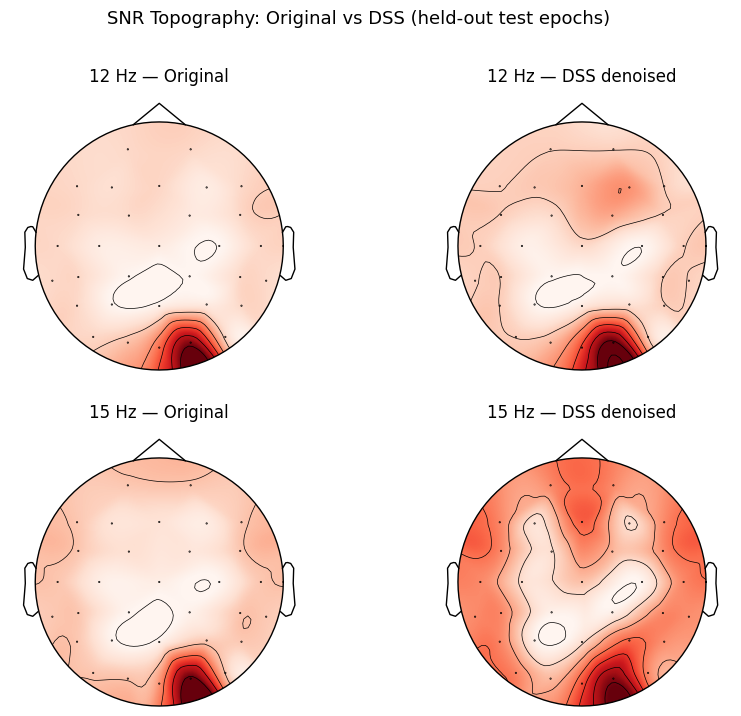

In [76]:

# --- Topography comparison: Original vs DSS ---
# Note: avoid tight_layout() with MNE topomaps — it breaks axes transforms.
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# 12 Hz
snr_topo_12_orig = snrs_12_orig[:, :, i12].mean(axis=0)
snr_topo_12_dss = snrs_12_dss[:, :, i12].mean(axis=0)
vlim_12 = (1, max(snr_topo_12_orig.max(), snr_topo_12_dss.max()))

mne.viz.plot_topomap(snr_topo_12_orig, epochs.info, vlim=vlim_12, axes=axes[0, 0], show=False)
axes[0, 0].set_title("12 Hz — Original")
mne.viz.plot_topomap(snr_topo_12_dss, epochs.info, vlim=vlim_12, axes=axes[0, 1], show=False)
axes[0, 1].set_title("12 Hz — DSS denoised")

# 15 Hz
snr_topo_15_orig = snrs_15_orig[:, :, i15].mean(axis=0)
snr_topo_15_dss = snrs_15_dss[:, :, i15].mean(axis=0)
vlim_15 = (1, max(snr_topo_15_orig.max(), snr_topo_15_dss.max()))

mne.viz.plot_topomap(snr_topo_15_orig, epochs.info, vlim=vlim_15, axes=axes[1, 0], show=False)
axes[1, 0].set_title("15 Hz — Original")
mne.viz.plot_topomap(snr_topo_15_dss, epochs.info, vlim=vlim_15, axes=axes[1, 1], show=False)
axes[1, 1].set_title("15 Hz — DSS denoised")

fig.suptitle("SNR Topography: Original vs DSS (held-out test epochs)", fontsize=13)
plt.show()


## Step 5 — Gold Standard #2: Standard CCA

Standard CCA is the widely used SSVEP detection/decoding baseline. We correlate
EEG with sine/cosine reference templates at each candidate frequency (+ harmonics)
and pick the max-correlation class. **No training needed** (template-based), which
makes it a clean comparator.

We implement canonical CCA using `scipy.linalg` and compare detection accuracy
to DSS-enhanced CCA.

In [74]:
from numpy.linalg import svd


def cca_reference(f_stim, sfreq, n_samples, n_harmonics=3):
    """Build sine/cosine reference matrix for CCA at f_stim + harmonics."""
    t = np.arange(n_samples) / sfreq
    refs = []
    for h in range(1, n_harmonics + 1):
        refs.append(np.sin(2 * np.pi * h * f_stim * t))
        refs.append(np.cos(2 * np.pi * h * f_stim * t))
    return np.array(refs).T  # (n_samples, 2*n_harmonics)


def cca_corr(X, Y):
    """Compute the first canonical correlation between X and Y.

    X: (n_samples, n_channels), Y: (n_samples, n_refs)
    Returns the maximum canonical correlation.
    """
    # Center
    X = X - X.mean(axis=0)
    Y = Y - Y.mean(axis=0)

    # QR decomposition for numerical stability
    Qx, Rx = np.linalg.qr(X, mode="reduced")
    Qy, Ry = np.linalg.qr(Y, mode="reduced")

    # SVD of cross-covariance
    _, s, _ = svd(Qx.T @ Qy, full_matrices=False)
    return s[0]  # first (largest) canonical correlation


def classify_ssvep_cca(epoch_data, sfreq, candidate_freqs, n_harmonics=3):
    """Classify one epoch via standard CCA.

    epoch_data: (n_channels, n_samples)
    Returns: index of the best matching frequency.
    """
    n_samples = epoch_data.shape[1]
    X = epoch_data.T  # (n_samples, n_channels)

    corrs = []
    for f in candidate_freqs:
        Y = cca_reference(f, sfreq, n_samples, n_harmonics)
        corrs.append(cca_corr(X, Y))
    return np.argmax(corrs), corrs


# --- Run CCA classification on test epochs (original vs DSS-denoised) ---
candidate_freqs = [12.0, 15.0]
n_harmonics_cca = 3

def evaluate_cca(epochs_12_obj, epochs_15_obj, label=""):
    """Evaluate CCA accuracy on 12 Hz and 15 Hz test epochs."""
    correct = 0
    total = 0
    all_corrs = []

    for ep in epochs_12_obj.get_data():
        pred, corrs = classify_ssvep_cca(ep, sfreq, candidate_freqs, n_harmonics_cca)
        correct += int(pred == 0)  # 12 Hz = index 0
        total += 1
        all_corrs.append(corrs)

    for ep in epochs_15_obj.get_data():
        pred, corrs = classify_ssvep_cca(ep, sfreq, candidate_freqs, n_harmonics_cca)
        correct += int(pred == 1)  # 15 Hz = index 1
        total += 1
        all_corrs.append(corrs)

    acc = correct / total
    print(f"  {label}: accuracy = {correct}/{total} = {acc:.1%}")
    return acc, np.array(all_corrs)


print("=== Gold Standard #2: CCA Classification (test epochs) ===")
acc_orig, corrs_orig = evaluate_cca(epochs_12_test, epochs_15_test, "Original")
acc_dss, corrs_dss = evaluate_cca(epochs_12_dss, epochs_15_dss, "DSS-denoised")

=== Gold Standard #2: CCA Classification (test epochs) ===
  Original: accuracy = 10/10 = 100.0%
  DSS-denoised: accuracy = 10/10 = 100.0%


## Summary — Benchmark Results

Collect all metrics into a single comparison table.

In [75]:
print("=" * 65)
print("SSVEP DSS BENCHMARK — SUMMARY (held-out test epochs)")
print("=" * 65)
print()
print("Gold Standard #1: Occipital ROI SNR at target frequency")
print(f"  {'Condition':<12} {'Original':>10} {'DSS':>10} {'Δ':>10}")
print(f"  {'12 Hz':<12} {snr_12_orig_roi:>10.2f} {snr_12_dss_roi:>10.2f} {snr_12_dss_roi - snr_12_orig_roi:>+10.2f}")
print(f"  {'15 Hz':<12} {snr_15_orig_roi:>10.2f} {snr_15_dss_roi:>10.2f} {snr_15_dss_roi - snr_15_orig_roi:>+10.2f}")
print()
print("Gold Standard #2: CCA Classification Accuracy")
print(f"  {'Original':>12}: {acc_orig:.1%}")
print(f"  {'DSS-denoised':>12}: {acc_dss:.1%}")
print()
print(f"DSS components used: {n_components}")
print(f"DSS harmonics: 3 (fundamental + 2 harmonics)")
print(f"Train/test split: alternating epochs (even=train, odd=test)")
print("=" * 65)

SSVEP DSS BENCHMARK — SUMMARY (held-out test epochs)

Gold Standard #1: Occipital ROI SNR at target frequency
  Condition      Original        DSS          Δ
  12 Hz             40.65      46.42      +5.77
  15 Hz             25.74      32.41      +6.67

Gold Standard #2: CCA Classification Accuracy
      Original: 100.0%
  DSS-denoised: 100.0%

DSS components used: 5
DSS harmonics: 3 (fundamental + 2 harmonics)
Train/test split: alternating epochs (even=train, odd=test)
